In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
customers = pd.read_csv("data/csv/customers.csv")
orders = pd.read_csv("data/csv/orders.csv")
products = pd.read_csv("data/csv/products.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Support Tickets:", support_tickets.shape)

Customers: (862, 12)
Orders: (3388, 10)
Products: (15, 6)
Support Tickets: (520, 8)


Station B — Python cleaning and EDA

Inspect the data

In [ ]:
print("CUSTOMERS")
print(customers.info())

print("\nORDERS")
print(orders.info())

print("\nPRODUCTS")
print(products.info())

print("\nSUPPORT TICKETS")
print(support_tickets.info())

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       862 non-null    int64  
 1   first_name        862 non-null    str    
 2   last_name         862 non-null    str    
 3   email             862 non-null    str    
 4   phone             845 non-null    str    
 5   city              862 non-null    str    
 6   state             862 non-null    str    
 7   signup_date       862 non-null    str    
 8   plan              862 non-null    str    
 9   age               835 non-null    float64
 10  last_active_date  862 non-null    str    
 11  churned           862 non-null    int64  
dtypes: float64(1), int64(2), str(9)
memory usage: 80.9 KB
None

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 3388 entries, 0 to 3387
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------

Check Missing Values

In [ ]:
print("Missing values in Customers:")
print(customers.isnull().sum())

print("\nMissing values in Orders:")
print(orders.isnull().sum())

print("\nMissing values in Products:")
print(products.isnull().sum())

print("\nMissing values in Support Tickets:")
print(support_tickets.isnull().sum())

Missing values in Customers:
customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64

Missing values in Orders:
order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64

Missing values in Products:
product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64

Missing values in Support Tickets:
ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64


Check Duplicate Records

In [ ]:
# Check duplicate rows
print("Duplicate rows in Customers:", customers.duplicated().sum())
print("Duplicate rows in Orders:", orders.duplicated().sum())

print("Duplicate rows in Products:", products.duplicated().sum())
print("Duplicate rows in Support Tickets:", support_tickets.duplicated().sum())

Duplicate rows in Customers: 0
Duplicate rows in Orders: 0
Duplicate rows in Products: 0
Duplicate rows in Support Tickets: 0


In [ ]:
# Check for invalid email formats
email_pattern = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'
invalid_emails = customers[~customers["email"].str.match(email_pattern, na=False)]
print("Invalid email records:", len(invalid_emails))
print(invalid_emails[["customer_id", "email"]].head(20))

Invalid email records: 20
     customer_id                         email
40         10041      noahsilva41 at gmail.com
81         10082   hannahnguyen82 at gmail.com
122        10123    ryanwalker123 at gmail.com
163        10164      ethankim164 at gmail.com
204        10205   imanibrooks205 at gmail.com
245        10246    gracereyes246 at gmail.com
286        10287  hannahnguyen287 at gmail.com
327        10328    noahfoster328 at gmail.com
368        10369    chrispatel369 at gmail.com
409        10410    diegopatel410 at gmail.com
450        10451    ryanfoster451 at gmail.com
491        10492     ethanshah492 at gmail.com
532        10533   elenamorgan533 at gmail.com
573        10574     miawalker574 at gmail.com
614        10615    liamhughes615 at gmail.com
655        10656   imanibrooks656 at gmail.com
696        10697     diegokhan697 at gmail.com
737        10738    fatimashah738 at gmail.com
778        10779   chrisbrooks779 at gmail.com
819        10820   chrisfoster820 

In [8]:
# Fix the obvious " at " email formatting issue
customers["email"] = customers["email"].str.replace(" at ", "@", regex=False)
invalid_emails_after = customers[~customers["email"].str.match(email_pattern, na=False)]
print("Invalid emails after cleaning:", len(invalid_emails_after))

Invalid emails after cleaning: 0


In [9]:
# Check phone number format
phone_pattern = r'^\+?[0-9\s\-\(\)]{10,15}$'
invalid_phones = customers[
    customers["phone"].notna() &
    ~customers["phone"].str.match(phone_pattern, na=False)]
print("Missing phone numbers:", customers["phone"].isna().sum())
print("Invalid phone numbers:", len(invalid_phones))
print("\nExamples of invalid phone numbers:")
print(invalid_phones[["customer_id", "phone"]].head(20))

Missing phone numbers: 17
Invalid phone numbers: 0

Examples of invalid phone numbers:
Empty DataFrame
Columns: [customer_id, phone]
Index: []


In [11]:
# Find duplicate customer emails
duplicate_emails = (
    customers[customers["email"].duplicated(keep=False)]
    .sort_values("email"))
print("Customers involved in duplicate emails:", len(duplicate_emails))
print("\nDuplicate email records:")
print(duplicate_emails[["customer_id", "first_name", "last_name", "email"]].to_string(index=False))

Customers involved in duplicate emails: 24

Duplicate email records:
 customer_id first_name last_name                              email
       10136      Amara    Nguyen amara.nguyen136@pulsecart-mail.com
       20011      amara    Nguyen amara.nguyen136@pulsecart-mail.com
       20002      arjun       Ali             arjun.ali684@gmail.com
       10684      Arjun       Ali             arjun.ali684@gmail.com
       20001      diego    Foster          diego.foster827@gmail.com
       10827      Diego    Foster          diego.foster827@gmail.com
       20010      grace     Reyes         grace.reyes580@outlook.com
       10580      Grace     Reyes         grace.reyes580@outlook.com
       20007        leo       Rao               leo.rao325@yahoo.com
       10325        Leo       Rao               leo.rao325@yahoo.com
       20003       nina    Morgan         nina.morgan307@outlook.com
       10307       Nina    Morgan         nina.morgan307@outlook.com
       20012      priya     Reyes 

In [12]:
# Keep the customer with the lower customer_id when the same email appears more than once.
customers_clean = (customers
    .sort_values("customer_id")
    .drop_duplicates(subset="email", keep="first")
    .copy()
)
print("Original customer records:", len(customers))
print("Customer records after deduplication:", len(customers_clean))
print("Duplicate records removed from analysis:",len(customers) - len(customers_clean))

Original customer records: 862
Customer records after deduplication: 850
Duplicate records removed from analysis: 12


Check orphon orders

In [13]:
# Find orders whose customer_id does not exist in the original customer dataset.
orphan_orders = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
].copy()
print("Orphan orders:", len(orphan_orders))
print("\nSample orphan orders:")
print(orphan_orders[["order_id", "customer_id", "product_id", "order_date"] ].head(20).to_string(index=False))

Orphan orders: 25

Sample orphan orders:
 order_id  customer_id  product_id order_date
    90001        39999        1011 2025-01-30
    90002        39999        1015 2025-07-16
    90003        39999        1002 2025-12-14
    90004        39999        1006 2025-08-29
    90005        39999        1013 2026-03-12
    90006        39999        1011 2026-02-14
    90007        39999        1010 2025-10-09
    90008        39999        1004 2026-05-24
    90009        39999        1011 2026-03-18
    90010        39999        1008 2025-04-02
    90011        39999        1013 2026-04-07
    90012        39999        1010 2026-03-17
    90013        39999        1014 2025-07-01
    90014        39999        1011 2025-06-23
    90015        39999        1004 2025-05-04
    90016        39999        1007 2026-02-19
    90017        39999        1015 2026-01-03
    90018        39999        1012 2026-07-08
    90019        39999        1002 2026-07-29
    90020        39999        1014 2025

In [14]:
# Keep only orders linked to the cleaned customer data
orders_clean = orders[
    orders["customer_id"].isin(customers_clean["customer_id"])
].copy()
print("Original orders:", len(orders))
print("Orphan orders:", len(orphan_orders))
print("Orders after cleaning:", len(orders_clean))

Original orders: 3388
Orphan orders: 25
Orders after cleaning: 3363


In [18]:
# Calculate churn rate by city
city_churn = (
    customers_clean
    .groupby("city")
    .agg(total_customers=("customer_id", "count"), churned_customers=("churned", "sum") )
    .reset_index())

city_churn["churn_rate"] = (
    city_churn["churned_customers"]
    / city_churn["total_customers"]
    * 100)

city_churn = city_churn.sort_values("churn_rate", ascending=False)
print(city_churn)

      city  total_customers  churned_customers  churn_rate
6  Houston              188                 57   30.319149
9  Seattle               60                 10   16.666667
3  Chicago              106                 17   16.037736
4   Dallas              120                 17   14.166667
0  Atlanta               82                 10   12.195122
7    Miami               45                  5   11.111111
8  Phoenix               56                  6   10.714286
1   Austin               94                 10   10.638298
2   Boston               40                  4   10.000000
5   Denver               59                  5    8.474576


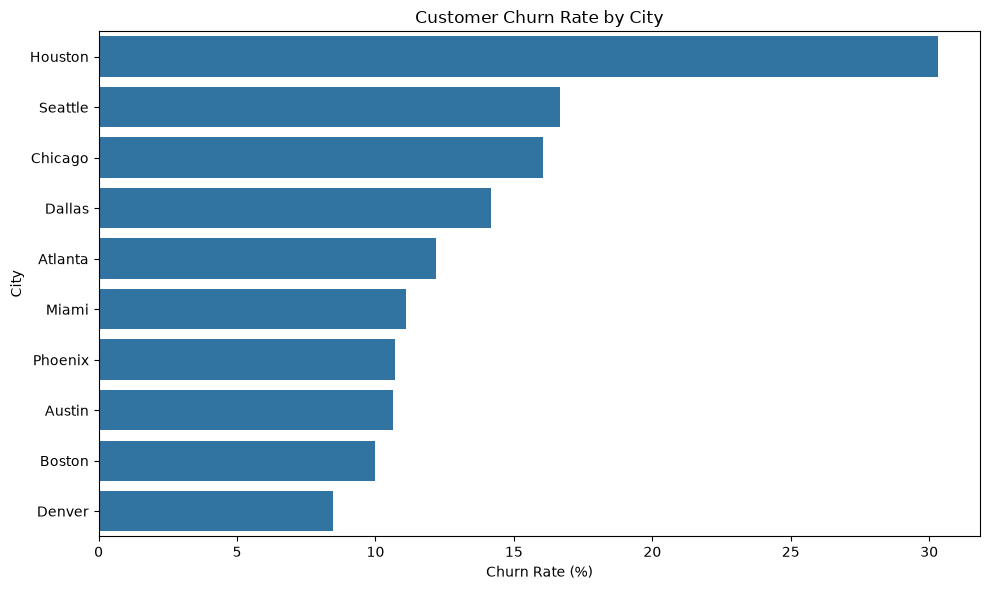

In [23]:
# Plot churn rate by city
plt.figure(figsize=(10, 6))
sns.barplot(data=city_churn, x="churn_rate", y="city")
plt.title("Customer Churn Rate by City")
plt.xlabel("Churn Rate (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### What the city churn chart tells us

Houston has the highest observed churn rate at about 30.3%, while the other cities are below 17%.

This does not prove that location causes churn, but it gives us a clear city-level difference to investigate further in the statistics and modeling stations.

In [21]:
# Calculate return rate by product category
category_returns = (
    orders_clean
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category")
    .agg(total_orders=("order_id", "count"), returned_orders=("returned", "sum"))
    .reset_index())

category_returns["return_rate"] = (
    category_returns["returned_orders"]
    / category_returns["total_orders"]
    * 100
)

category_returns = category_returns.sort_values("return_rate", ascending=False)
print(category_returns)

      category  total_orders  returned_orders  return_rate
3      Kitchen           713              170    23.842917
2         Home           650               52     8.000000
4    Wearables           683               54     7.906296
1        Audio           644               36     5.590062
0  Accessories           673               30     4.457652


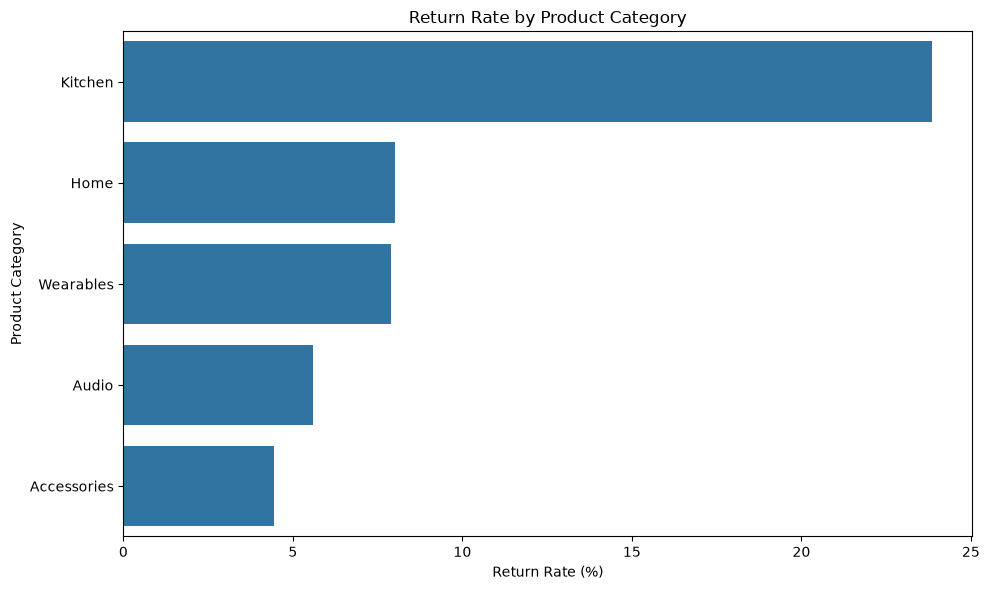

In [22]:
# Plot return rate by product category
plt.figure(figsize=(10, 6))
sns.barplot(data=category_returns, x="return_rate", y="category")
plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### What the category return chart tells us

Kitchen has the highest observed return rate at about 23.8%, while the other categories are below 8%.

This makes Kitchen a useful category to investigate further, especially at the product level. The later statistical test will check whether this difference is large enough to treat as evidence rather than just a sample difference.

In [24]:
# Check product price statistics
print(products["list_price"].describe())

count     15.000000
mean      78.066667
std       52.258242
min       15.000000
25%       36.500000
50%       69.000000
75%      104.000000
max      199.000000
Name: list_price, dtype: float64


In [25]:
# Detect price outliers using the IQR method
Q1 = products["list_price"].quantile(0.25)
Q3 = products["list_price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
price_outliers = products[(products["list_price"] < lower_limit) | (products["list_price"] > upper_limit)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

print("\nPotential price outliers:")
print(price_outliers[["product_id", "product_name", "category", "list_price"]].to_string(index=False))
print("\nNumber of potential outliers:", len(price_outliers))

Q1: 36.5
Q3: 104.0
IQR: 67.5
Lower limit: -64.75
Upper limit: 205.25

Potential price outliers:
Empty DataFrame
Columns: [product_id, product_name, category, list_price]
Index: []

Number of potential outliers: 0


In [27]:
# Check if any product has a unit cost higher than its list price
impossible_prices = products[products["unit_cost"] > products["list_price"]]
print("Products with unit cost greater than list price:", len(impossible_prices))
print(impossible_prices[["product_id", "product_name", "unit_cost", "list_price"]].to_string(index=False))

Products with unit cost greater than list price: 0
Empty DataFrame
Columns: [product_id, product_name, unit_cost, list_price]
Index: []


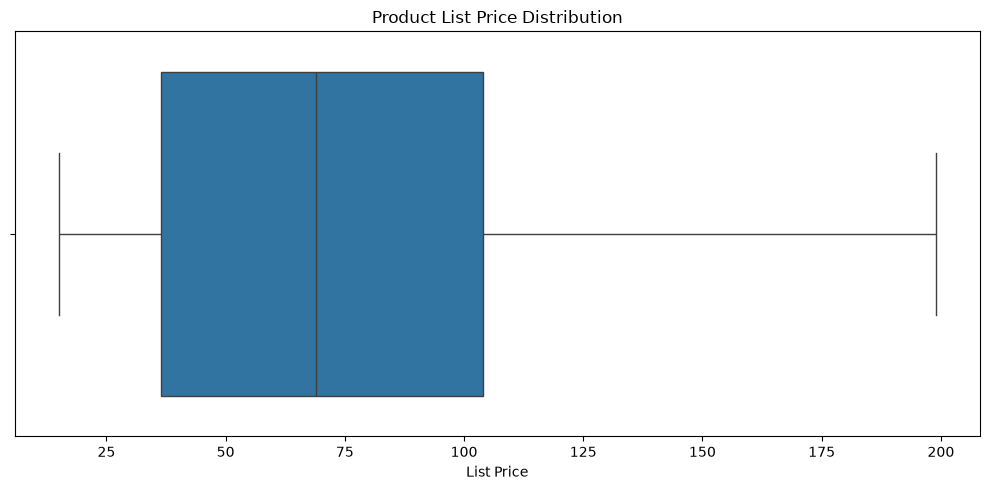

In [30]:
# Check product price distribution and possible outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=products, x="list_price")
plt.title("Product List Price Distribution")
plt.xlabel("List Price")
plt.tight_layout()
plt.show()

### What the price plot tells us

The product prices range from $15 to $199.

Using the 1.5 × IQR rule, no statistical price outliers were detected, so there is no reason to remove a product based on price alone.

The separate business-rule check above is used to catch prices that may be impossible even if they are not statistical outliers.